<a href="https://colab.research.google.com/github/Prakshi16/Handwritten-Digit-Recognition/blob/main/Handwritten_ANN_uploadImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


Load MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Normalize

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0


Build the model

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Train

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8478 - loss: 0.5221 - val_accuracy: 0.9655 - val_loss: 0.1293
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9535 - loss: 0.1605 - val_accuracy: 0.9718 - val_loss: 0.0999
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9647 - loss: 0.1186 - val_accuracy: 0.9752 - val_loss: 0.0866
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9724 - loss: 0.0900 - val_accuracy: 0.9770 - val_loss: 0.0792
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9771 - loss: 0.0744 - val_accuracy: 0.9777 - val_loss: 0.0729


Test Accuracy

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9732 - loss: 0.0865
Test accuracy: 0.9767000079154968


Upload Image

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving YNtQ6.jpg to YNtQ6 (1).jpg


Predict the Digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted digit: 7


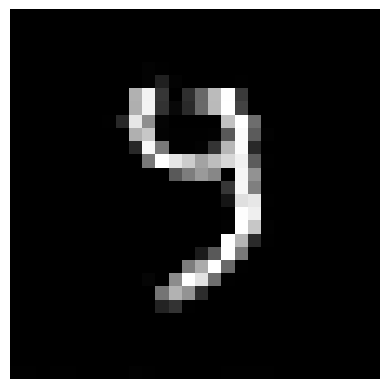

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    list(uploaded.keys())[0],
    color_mode='grayscale',
    target_size=(28, 28)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = img_array.reshape(1, 28, 28)

plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.axis('off')

prediction = model.predict(img_array)
print("Predicted digit:", np.argmax(prediction))
